# 2일차 5교시 실습 · HSV 기반 색상 객체 검출
준비 셀부터 순서대로 실행합니다. 빈칸 A는 강의자료 PDF 5페이지, B는 6페이지에서 확인합니다. 좌표는 제공 이미지의 왼쪽 위가 원점이며 (x, y) 순서입니다.


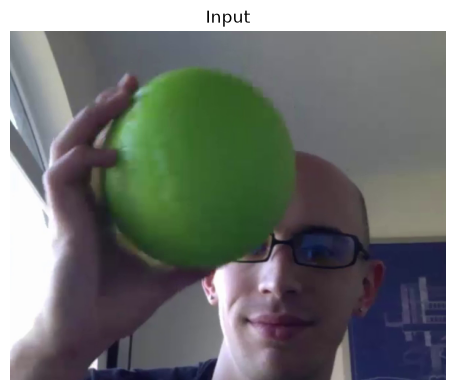

In [20]:
from pathlib import Path
import cv2
import numpy as np
from hsv_helpers import read_image, show, candidates, compare, video_samples, run_camera

data = Path("data")
frame = read_image(data / "frame.png")
colors = read_image(data / "colors.png")
lower = (35, 80, 60)
upper = (85, 255, 255)
show([frame], ["Input"])

## RGB로 먼저 선택 · 강의자료 PDF 2~3페이지
RGB로도 범위 선택이 가능합니다. 아래 값은 이 이미지에 적용한 설정값입니다. 두 측정 지점은 설명을 위해 수동 지정했습니다.


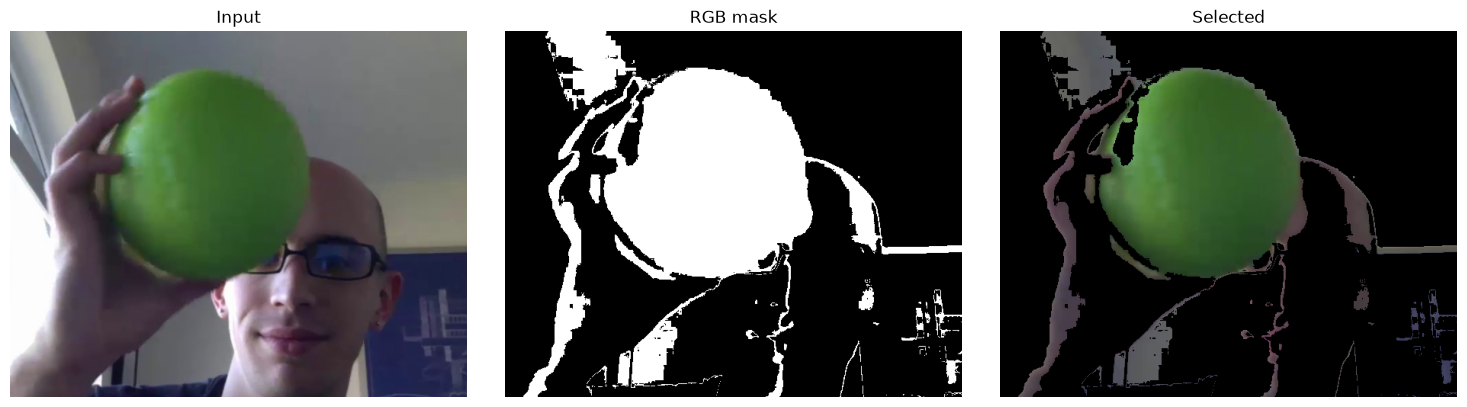

RGB: [53, 102, 38]
RGB: [45, 86, 38]


In [21]:
rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
rgb_mask = cv2.inRange(rgb, (20,60,0), (120,180,100))
rgb_selected = cv2.bitwise_and(frame, frame, mask=rgb_mask)
show([frame, rgb_mask, rgb_selected], ["Input", "RGB mask", "Selected"])
for x, y in [(245,140), (320,235)]:
    print("RGB:", rgb[y,x].tolist())

## 색상 마스크 함수 · 강의자료 PDF 5, 6페이지
A: BGR → HSV 변환 상수 / B: 범위 안 픽셀을 선택하는 함수. 두 빈칸을 채운 뒤 실행합니다.


In [22]:
def color_mask(frame, lower, upper):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)  # A: PPT 5
    mask = cv2.inRange(hsv, lower, upper)  # B: PPT 6
    return mask

mask = color_mask(frame, lower, upper)
selected = cv2.bitwise_and(frame, frame, mask=mask)
show([frame, mask, selected], ["Input", "Mask", "Selected"])
print("Selected pixels:", cv2.countNonZero(mask))

KeyboardInterrupt: 

## H 범위 비교 · 강의자료 PDF 7페이지
S와 V 범위는 고정합니다.


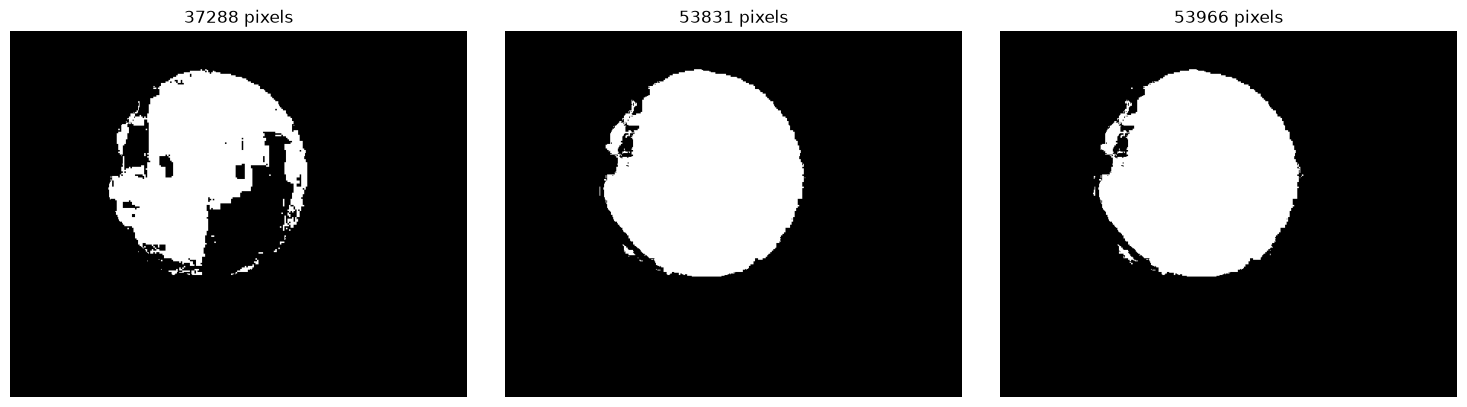

[37288, 53831, 53966]


In [ ]:
h_counts = compare(frame, color_mask, [((48,80,60),(54,255,255)), ((35,80,60),(85,255,255)), ((0,80,60),(100,255,255))])
print(h_counts)

## S 하한 비교 · 강의자료 PDF 8페이지
H와 V 범위는 고정합니다.


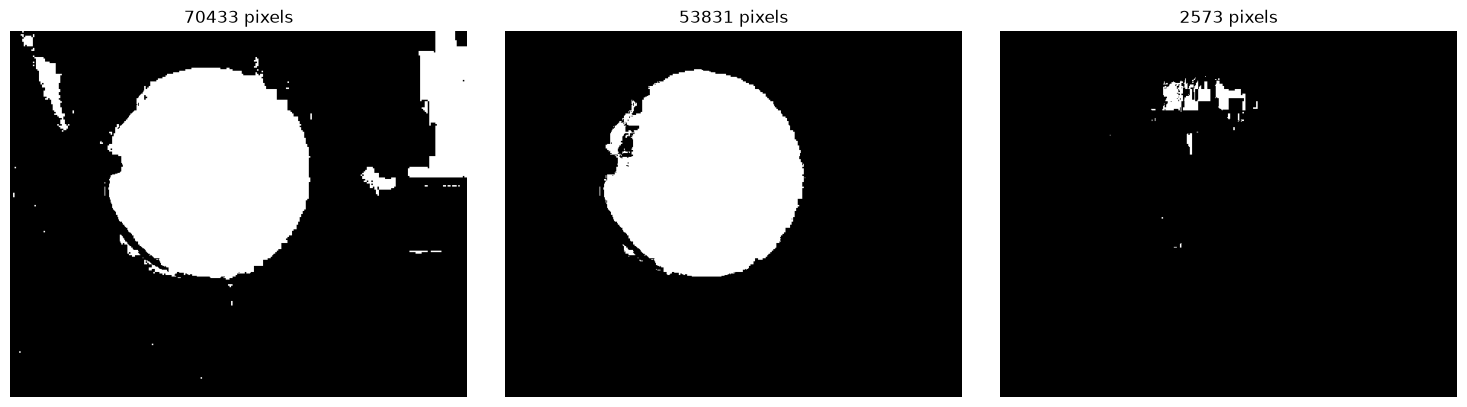

[70433, 53831, 2573]


In [ ]:
s_counts = compare(frame, color_mask, [((35,0,60),upper), (lower,upper), ((35,160,60),upper)])
print(s_counts)

## V 하한 비교 · 강의자료 PDF 9페이지
H와 S 범위는 고정합니다. 입력 영상 자체를 밝게 만들거나 어둡게 만들지는 않습니다.


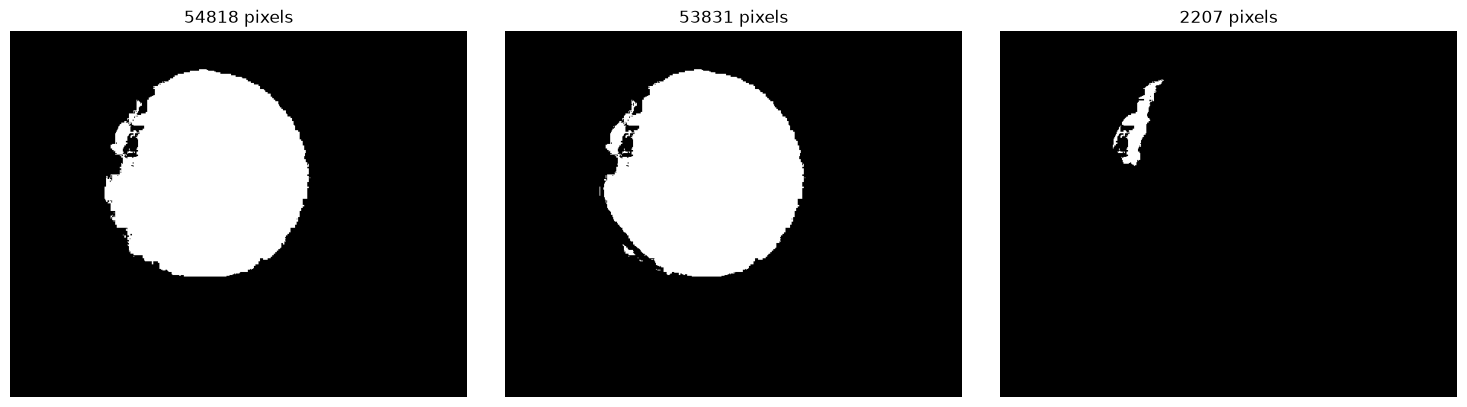

[54818, 53831, 2207]


In [ ]:
v_counts = compare(frame, color_mask, [((35,80,0),upper), (lower,upper), ((35,80,150),upper)])
print(v_counts)

## 바운딩 박스와 중심 · 강의자료 PDF 10페이지
반환값은 (x, y, 너비, 높이, 중심 x, 중심 y)입니다. 후보의 Contour 면적은 300 pixel² 이상으로 제한합니다.


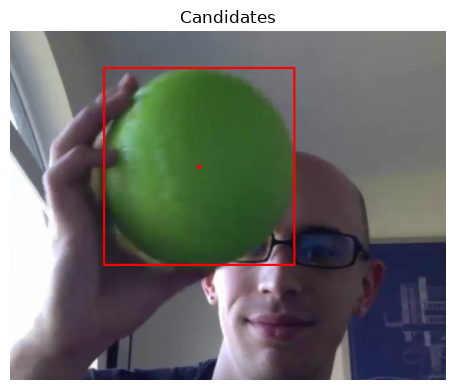

[(129, 50, 263, 272, 260.5, 186.0)]


In [ ]:
result, boxes = candidates(frame, mask)
show([result], ["Candidates"])
print(boxes)

## 같은 색의 다른 물체 · 강의자료 PDF 11페이지
녹색 범위는 유지합니다. 작은 사진에 맞춰 최소 후보 면적은 100 pixel²를 사용합니다.


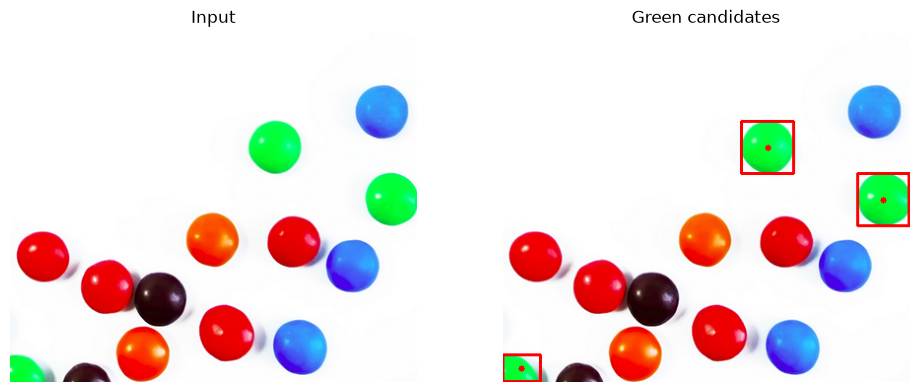

Candidates: 3


In [ ]:
green_mask = color_mask(colors, lower, upper)
green_result, green_boxes = candidates(colors, green_mask, min_area=100)
show([colors, green_result], ["Input", "Green candidates"])
print("Candidates:", len(green_boxes))

## 밝기 가공 비교 · 강의자료 PDF 12페이지
원본 BGR 값을 0.35배한 비교용 입력입니다. 실제 촬영 조건을 바꾼 사진이 아닙니다. HSV 선택 범위는 그대로 유지합니다.


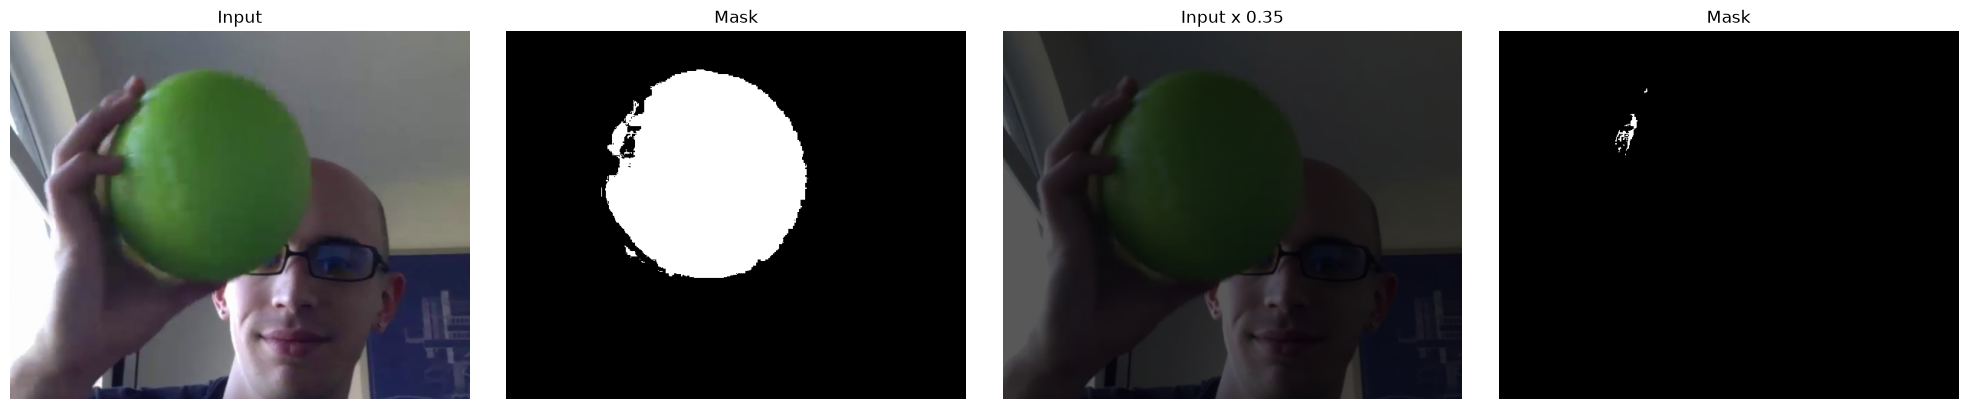

53831 372


In [ ]:
dark = read_image(data / "dark.png")
dark_mask = color_mask(dark, lower, upper)
show([frame, mask, dark, dark_mask], ["Input", "Mask", "Input x 0.35", "Mask"])
print(cv2.countNonZero(mask), cv2.countNonZero(dark_mask))

## 조건 하나 변경 · 강의자료 PDF 13페이지
S 하한만 80에서 0으로 바꾸어 새로 포함된 영역을 확인합니다.


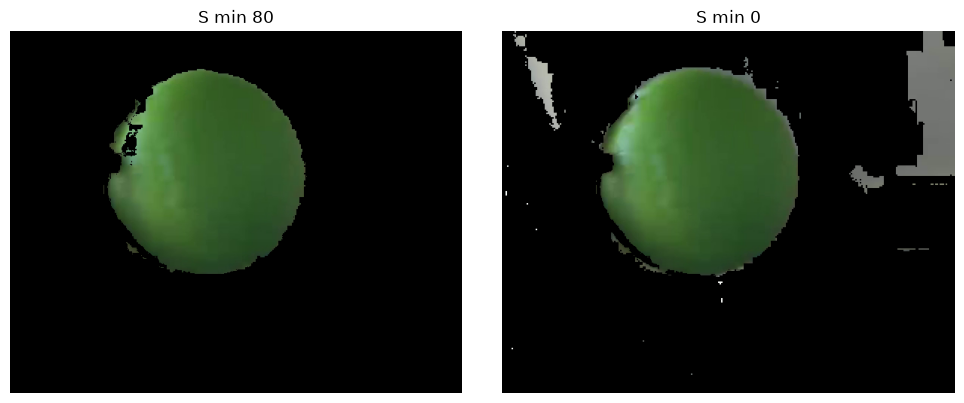

In [ ]:
changed_mask = color_mask(frame, (35,0,60), upper)
changed = cv2.bitwise_and(frame, frame, mask=changed_mask)
show([selected, changed], ["S min 80", "S min 0"])

## 각 프레임의 검출 · 강의자료 PDF 14페이지
제공 영상은 원본의 Frame 40~240을 같은 위치로 자른 무손실 영상입니다. 파일 내 10, 60, 160번 프레임이 강의자료 PDF의 원본 50, 100, 200번 프레임에 대응합니다. 번호는 0부터 시작합니다. 이전 프레임의 후보와 연결하지 않습니다.


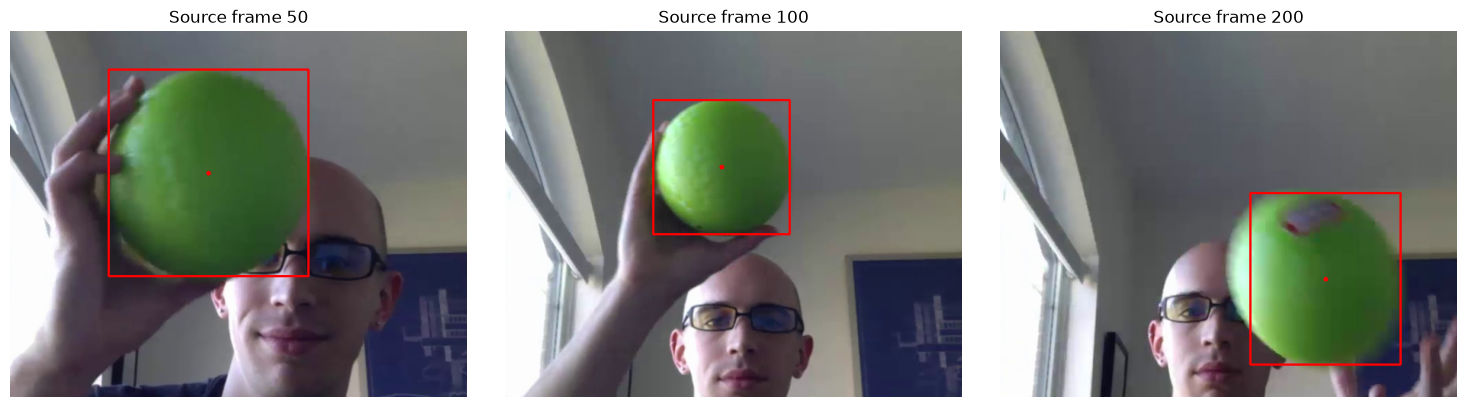

Processed frames: 201
[[(129, 50, 263, 272, 260.5, 186.0)], [(194, 90, 180, 177, 284.0, 178.5)], [(328, 212, 198, 226, 427.0, 325.0)]]


In [ ]:
# clip.avi 파일은 올리지 않음. 출처.md에 영상출처가 있음. 
frame_count, frame_boxes = video_samples(data / "clip.avi", color_mask, lower, upper)
print("Processed frames:", frame_count)
print(frame_boxes)

## 빨강의 두 범위 · 강의자료 PDF 15페이지


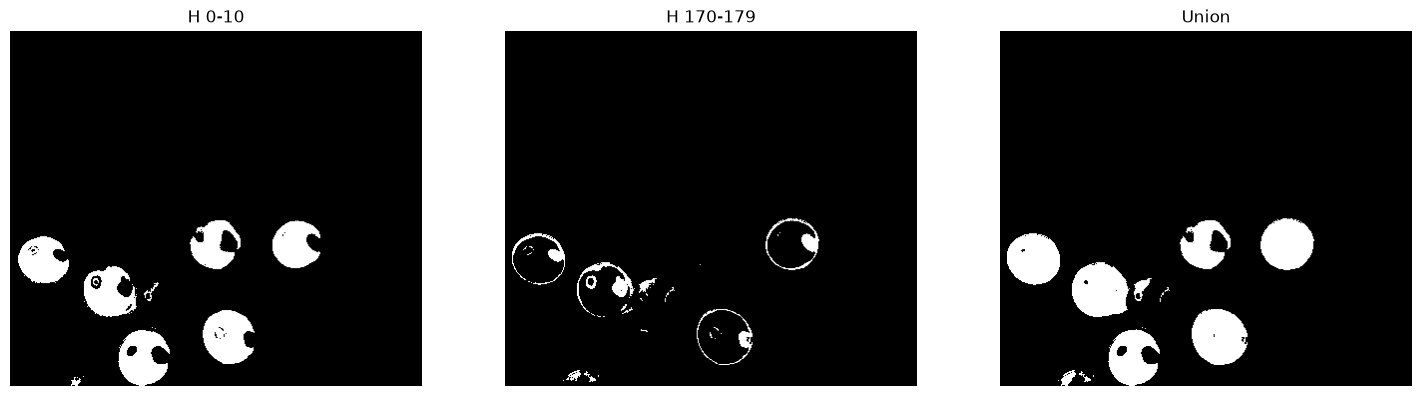

In [ ]:
mask_low = color_mask(colors, (0,80,60), (10,255,255))
mask_high = color_mask(colors, (170,80,60), (179,255,255))
red_mask = cv2.bitwise_or(mask_low, mask_high)
show([mask_low, mask_high, red_mask], ["H 0-10", "H 170-179", "Union"])

## 녹색과 파란색 후보를 따로 구하기 · 강의자료 PDF 16페이지


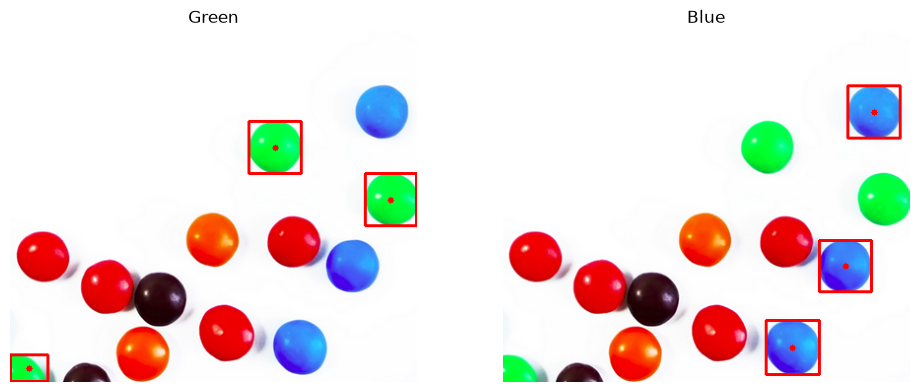

3 3


In [ ]:
blue_mask = color_mask(colors, (90,80,60), (140,255,255))
blue_result, blue_boxes = candidates(colors, blue_mask, min_area=100)
show([green_result, blue_result], ["Green", "Blue"])
print(len(green_boxes), len(blue_boxes))

## USB 카메라에 적용
로컬 Python 환경에서만 실행합니다. 카메라 영상에는 제공 이미지의 잘라내기 좌표를 적용하지 않습니다. 카메라와 조명에 따라 범위를 조정해야 합니다. 실행하려면 아래 값을 True로 바꾸고, 종료할 때 영상 창에서 q를 누릅니다.


In [25]:
# 그린마스크 원할경우...
# lower = (35, 80, 60)
# upper = (85, 255, 255)
lower = (90,80,60)
upper = (140,255,255)

RUN_CAMERA = True
if RUN_CAMERA:
    run_camera(color_mask, lower, upper, camera_id=2)  # ID 0 은 웹캠 


KeyboardInterrupt: 